Dataset loaded successfully.
Dataset shape: (1797, 64)
Number of classes: 10

Number of samples: 1797
Number of features: 64
Classes: [0 1 2 3 4 5 6 7 8 9]


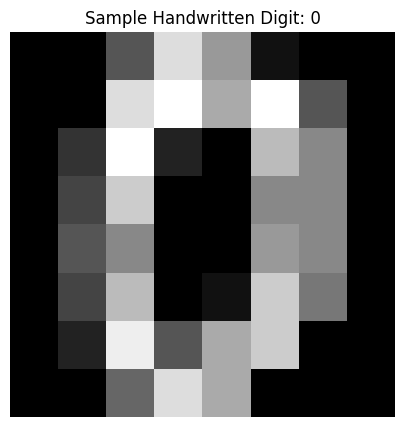

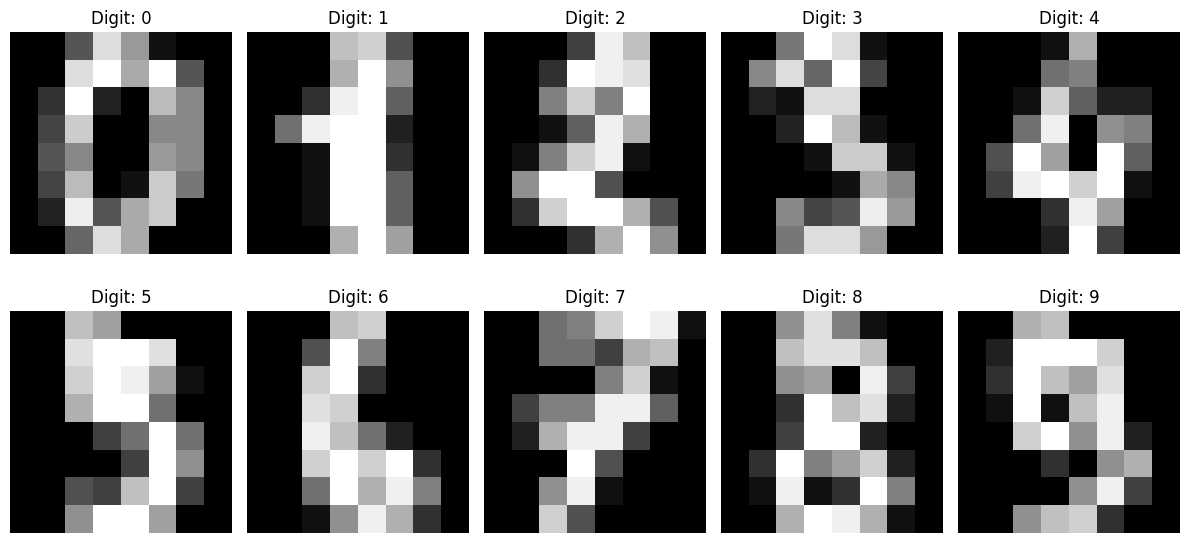


Training samples: 1437
Testing samples: 360

kNN classifier trained successfully.
Value of k: 3

First 20 actual labels:
[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 9 9]

First 20 predicted labels:
[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 9 9]

Classification Accuracy: 0.9861111111111112
Accuracy Percentage: 98.61111111111111 %

Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  0 32  0]
 [ 0  0  0  0  1  0  0  0  1 34]]


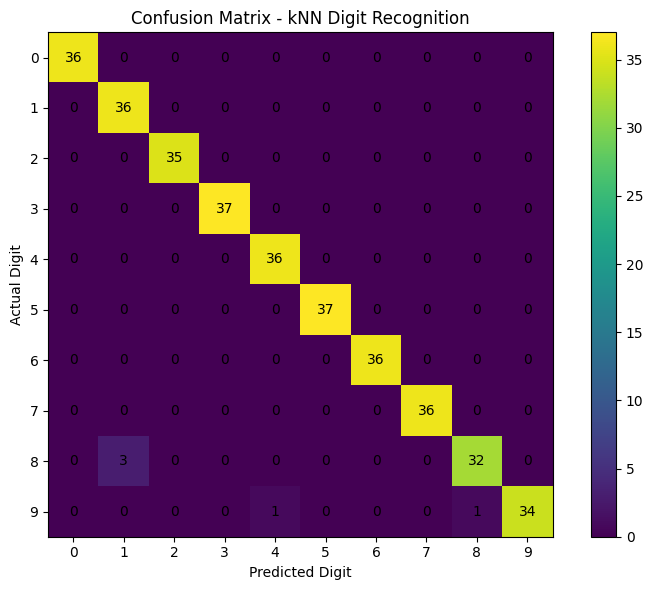


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9231    1.0000    0.9600        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    1.0000    1.0000        36
           7     1.0000    1.0000    1.0000        36
           8     0.9697    0.9143    0.9412        35
           9     1.0000    0.9444    0.9714        36

    accuracy                         0.9861       360
   macro avg     0.9866    0.9859    0.9859       360
weighted avg     0.9867    0.9861    0.9861       360



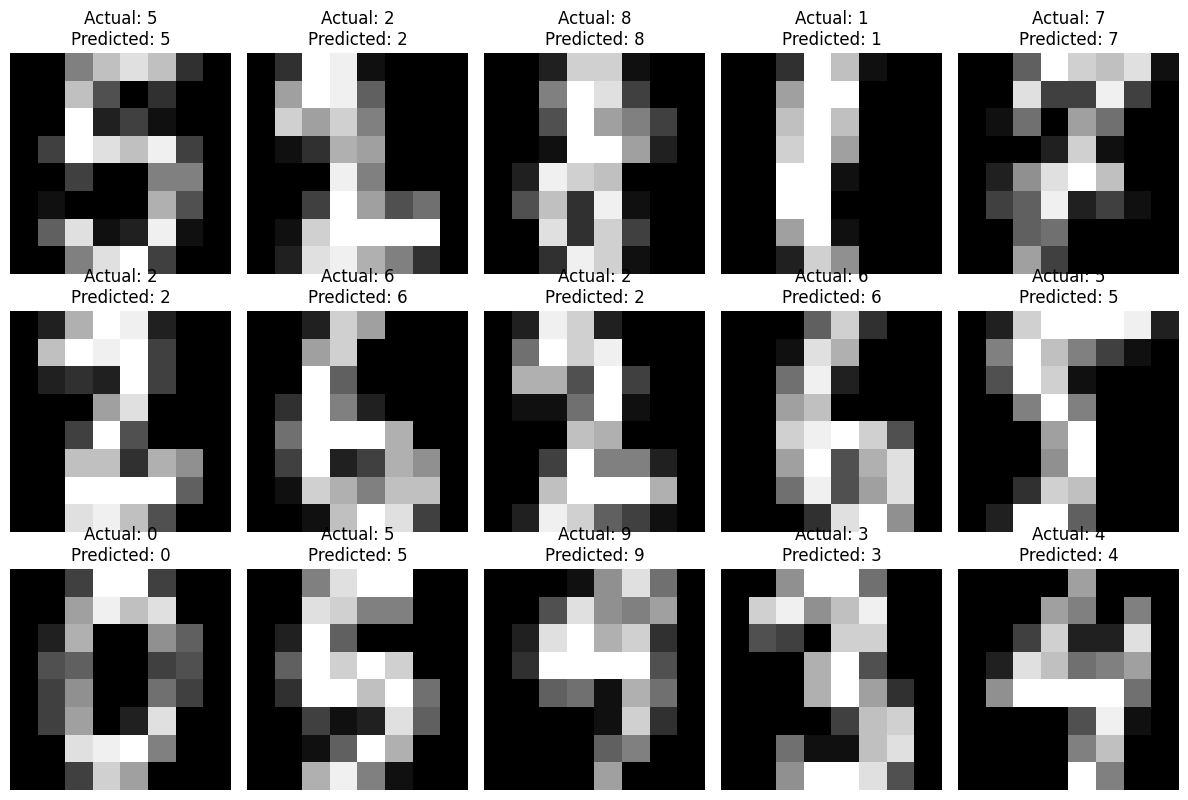


Selected Test Sample
Actual Digit: 0
Predicted Digit: 0


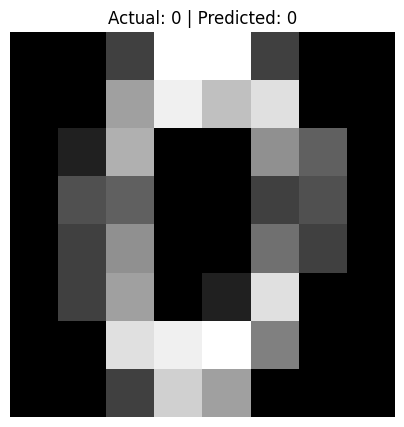


New Handwritten Digit Prediction:
Predicted Digit: 6

Handwritten digit recognition was successfully performed using kNN.
The handwritten digit images were converted into numerical feature vectors.
The kNN classifier identified new digits based on similarity with
the nearest training samples.
The model was evaluated using accuracy, confusion matrix,
and classification report.


In [4]:
# 1. Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Load the handwritten digit dataset

digits = load_digits()

X = digits.data
y = digits.target

print("Dataset loaded successfully.")
print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))


# 3. Display dataset information

print("\nNumber of samples:", len(X))
print("Number of features:", X.shape[1])
print("Classes:", np.unique(y))


# 4. Display a sample handwritten digit

plt.figure(figsize=(5, 5))

plt.imshow(
    digits.images[0],
    cmap='gray'
)

plt.title(f"Sample Handwritten Digit: {y[0]}")
plt.axis("off")
plt.show()


# 5. Display multiple handwritten digits

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        digits.images[i],
        cmap='gray'
    )

    plt.title(f"Digit: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# 6. Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# 7. Create and train the kNN classifier

k = 3

knn = KNeighborsClassifier(
    n_neighbors=k
)

knn.fit(
    X_train,
    y_train
)

print("\nkNN classifier trained successfully.")
print("Value of k:", k)


# 8. Make predictions

y_pred = knn.predict(X_test)

print("\nFirst 20 actual labels:")
print(y_test[:20])

print("\nFirst 20 predicted labels:")
print(y_pred[:20])


# 9. Calculate classification accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nClassification Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# 10. Display confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - kNN Digit Recognition")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# 11. Display classification report

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


# 12. Display test images with predictions

plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    image_index = np.where(
        np.all(X == X_test[i], axis=1)
    )[0][0]

    plt.imshow(
        digits.images[image_index],
        cmap='gray'
    )

    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# 13. Predict a new handwritten digit

sample_index = 10

sample = X_test[sample_index].reshape(1, -1)

prediction = knn.predict(sample)

print("\nSelected Test Sample")
print("Actual Digit:", y_test[sample_index])
print("Predicted Digit:", prediction[0])


# 14. Display the selected digit

image_index = np.where(
    np.all(X == X_test[sample_index], axis=1)
)[0][0]

plt.figure(figsize=(5, 5))

plt.imshow(
    digits.images[image_index],
    cmap='gray'
)

plt.title(
    f"Actual: {y_test[sample_index]} | Predicted: {prediction[0]}"
)

plt.axis("off")
plt.show()


# 15. Test the model with a manually selected digit

new_digit = X_test[20].reshape(1, -1)

new_prediction = knn.predict(new_digit)

print("\nNew Handwritten Digit Prediction:")
print("Predicted Digit:", new_prediction[0])


# 16. Conclusion

print("\nHandwritten digit recognition was successfully performed using kNN.")
print("The handwritten digit images were converted into numerical feature vectors.")
print("The kNN classifier identified new digits based on similarity with")
print("the nearest training samples.")
print("The model was evaluated using accuracy, confusion matrix,")
print("and classification report.")